In [1]:
from pathlib import Path

from matplotlib import pyplot as plt
from sbi.analysis import pairplot

from mach3sbitools.inference import InferenceHandler
from mach3sbitools.simulator import Simulator
from mach3sbitools.utils import MaCh3Logger, PosteriorConfig, TrainingConfig

MaCh3Logger("mach3sbitools")

2026-03-26 01:07:11.893509: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-26 01:07:11.905493: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774512431.918551 1478311 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774512431.922510 1478311 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774512431.934747 1478311 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
# Some global variables
BASE = Path("jupyter_tutorial")

DATA_FILE = BASE / "data/my_data.feather"
PRIOR_FILE = BASE / "prior/my_prior.pkl"
MODEL_FILE = BASE / "model/my_model.ckpt"
INFERENCE_FILE = BASE / "inference/my_inference.paraquet"

In [7]:
# Firstly we load the simulator
simulator = Simulator(
    module_name="my_simulator",
    class_name="MySimulator",
    config=Path("physics_configs/PhysicsConfig.yaml"),
)

# This should take ~2 mins
theta, x = simulator.simulate(400000)
simulator.save(DATA_FILE, theta, x)

simulator.prior.save(PRIOR_FILE)


Simulating:   0%|          | 0/200000 [00:00<?, ?it/s]

In [8]:
# Now we setup training
posterior_config = PosteriorConfig(
    model="maf",
    hidden_features=64,
    num_transforms=5,
    dropout_probability=0.1,
)

training_config = TrainingConfig(
    save_path=MODEL_FILE,
    max_epochs=2000,
    learning_rate=1e-4,
    show_progress=True,
    tensorboard_dir=BASE/"tensor-logs",
)

trainer = InferenceHandler(PRIOR_FILE)
trainer.set_dataset(DATA_FILE.parent)
trainer.load_training_data()
trainer.create_posterior(posterior_config)

Pre-loading dataset: 100%|██████████| 1/1 [00:00<00:00,  6.12it/s]

Loaded 200,000 simulations | θ: 4D  x: 19D | RAM: 0.02 GB


In [9]:
# Now we run training, this will take some time! 
trainer.train_posterior(training_config, model_config=posterior_config)

Output()

Early stopping at epoch 1760

In [10]:
# data_bins = simulator.simulator_wrapper.get_data_bins()
data_bins = simulator.simulator_wrapper.get_data_bins()
samples = trainer.sample_posterior(1_000_000, data_bins)

  0%|          | 0/1000000 [00:00<?, ?it/s]

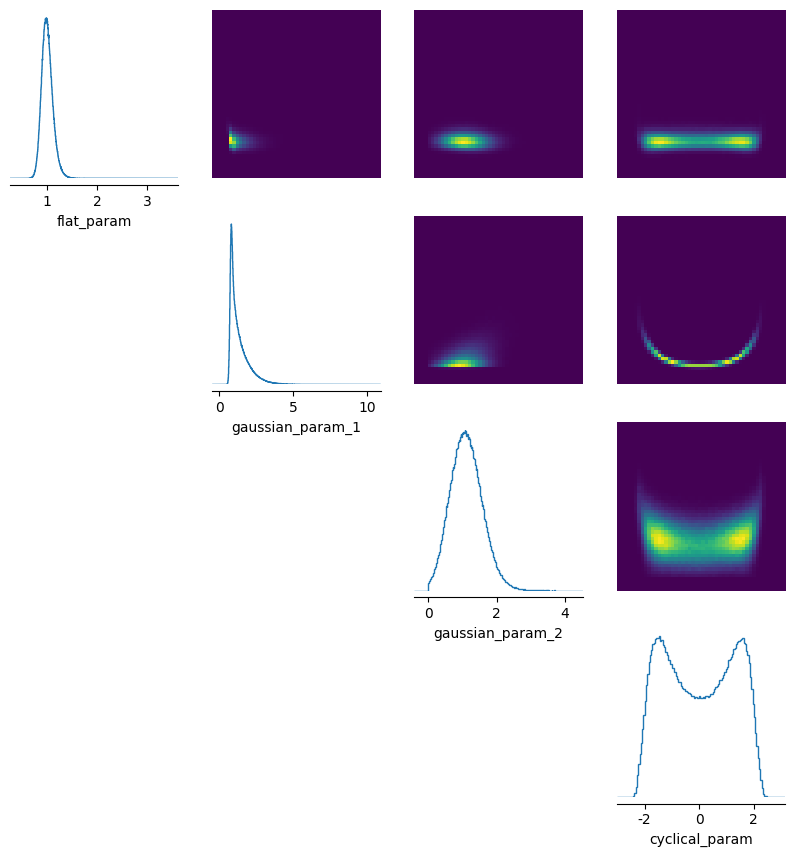

In [12]:
pairplot(samples.cpu().numpy(), labels=simulator.simulator_wrapper.get_parameter_names())
plt.show()